# Post-Treatement of the data
The aim of this notebook is to import the different simulations, and compute the different indices of quality as well as the volume.  
The indices we calculate are the following for the synthetic :
1. Sum of the error 
2. Absolute sum of the error
3. Normalized Sum
4. Standard Deviation
5. Mean

For the real data, we just compute the volume.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import pickle
import os
import time
from matplotlib.backends.backend_pdf import PdfPages
import georasters as gr


C:\Users\wdall\Anaconda3\envs\tsanfleuron_w\lib\site-packages\pysal\explore\segregation\network\network.py:16: UserWarning: You need pandana and urbanaccess to work with segregation's network module
You can install them with  `pip install urbanaccess pandana` or `conda install -c udst pandana urbanaccess`
  "You need pandana and urbanaccess to work with segregation's network module\n"
C:\Users\wdall\Anaconda3\envs\tsanfleuron_w\lib\site-packages\pysal\model\spvcm\abstracts.py:10: UserWarning: The `dill` module is required to use the sqlite backend fully.
  from .sqlite import head_to_sql, start_sql


Define the path of the data

In [159]:
path_output_krig = '../simulation_output_krig/'
path_output_MPS = '../simulation_output/'

simulation_name_krig = os.listdir(path_output_krig)
simulation_name = os.listdir(path_output_MPS)

exec(open('../functions/03_indice_calculation_functions.py').read())


In [160]:
simulation_name

['realisation1_simu.pickle']

In [161]:
file_path_DEM = '../data/DEM/tif/DEM_Glacier_Zone.tif'

if os.path.isfile(file_path_DEM):
    print('Le fichier est présent. import')
    data_DEM_Glacier = gr.from_file(file_path_DEM)

else:
    print('error')
    


Le fichier est présent. import


In the following cell, we will generate the 

In [162]:

all_output = []
real_vol = []
type_sim = ['MPS1','MPS2','GRF','KRIG']
for name, name_krig in zip(simulation_name,simulation_name_krig):
    it = 0
    with open(path_output_MPS+name,'rb') as file:
        real_alt, simus_sets, mask, referential= pickle.load(file)
    
    with open(path_output_krig+name_krig,'rb') as file:
         real_k, krieg_sets, mask, referential = pickle.load(file)

    for simus in simus_sets:        
        pro = indice_calculation(np.zeros(simus[0].shape),simus,'mps')
        
        all_output.append([name,type_sim[it]] + pro)
        it = it + 1
        
        
    #pro = indice_calculation(np.zeros(simus[0].shape),krieg_sets,'krig')
    all_output.append([name,type_sim[it]] + [0,0,0,krieg_sets[0],krieg_sets[1], 0])
results_frame = pd.DataFrame(data =all_output, columns=['Sim_name','Type','Error','Abs_error','Norm_Error','Mean','Sd','Volume'])



In [163]:
mask.shape

(1557, 3493)

In [173]:
simus_sets[0][0].shape

(1556, 3492)

In [165]:
ref
ref_DEM = [np.int(np.around((data_DEM_Glacier.geot[0]-referential[0])/2,decimals=0)),np.int(np.around((data_DEM_Glacier.geot[3]-referential[1])/-2,decimals=0))]

if ref_DEM[0]<0:
    glacier_to_add = data_DEM_Glacier.raster[:,-ref_DEM[0]:]
    ref_DEM[0] = 0
elif ref_DEM[1]<0:
    glacier_to_add = data_DEM_Glacier.raster[np.int(-ref_DEM[1]):,:]
    ref_DEM[1] = 0

full_dem = np.zeros(mask.shape)
full_dem[ref_DEM[1]:glacier_to_add.shape[0]+ref_DEM[1], ref_DEM[0]:glacier_to_add.shape[1]+ref_DEM[0]] = glacier_to_add

In [166]:
mask = mask == 1
full_dem[~mask] = np.nan


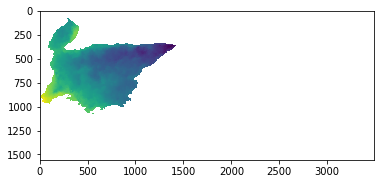

In [167]:
plt.imshow(full_dem)
plt.imshow(results_frame[results_frame['Type']=='MPS2'].Mean[1])

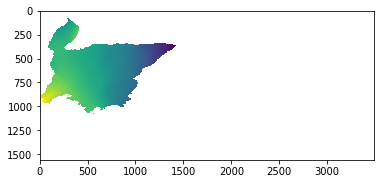

In [168]:
plt.imshow(full_dem)


In [171]:
for name, name_krig in zip(simulation_name,simulation_name_krig):

    with open(path_output_MPS+name,'rb') as file:
        real_alt, simus_sets, mask, referential= pickle.load(file)
    
    with open(path_output_krig+name_krig,'rb') as file:
         real_k, krieg_sets, mask, referential = pickle.load(file)

    for simus in simus_sets:        
        vol = []
        for sub in simus:
            vol.append(np.nansum(full_dem[:-1,:-1] - sub)*2)
        

In [172]:
vol

[76982256.26497532, 76594386.20815669]

In [ ]:
#np.shape(real_alt)
#real_alt.shape
simus_sets
results_frame

In [36]:
data_DEM_Glacier.geot[0]

582170.0

In [37]:
referential

[582190.2921, 131224.0]

In [18]:
results_frame

,Sim_name,Type,Error,Abs_error,Norm_Error,Mean,Sd,Volume
0,realisation1_simu.pickle,MPS1,NaN,NaN,NaN,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[nan, nan]"
1,realisation1_simu.pickle,MPS2,NaN,NaN,NaN,"[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[[nan, nan, nan, nan, nan, nan, nan, nan, nan,...","[nan, nan]"
2,realisation1_simu.pickle,GRF,1193.214343,1197.524464,3.275254e+11,"[[2001.4379336846064, 2003.3587890053068, 2004...","[[4.945621931932919, 4.412856135215293, 4.0547...","[-6225349884.530368, -6225213819.493546]"
3,realisation1_simu.pickle,KRIG,0.000000,0.000000,0.000000e+00,"[[2020.7123835216667, 2022.6201273288234, 2024...",None,0


In [15]:
dirName ='simu_reports'
numbers = []
try:
    # Create target Directory
    os.mkdir(dirName)
    print("Directory " , dirName ,  " Created ") 
    pdf_name = 'pdf_report_001.pdf'
except FileExistsError:
    print("Directory " , dirName ,  " already exists")
    pdf_name = os.listdir(dirName)
    for pdf_me in pdf_name:
        numbers.append(pdf_me[11:12])
    pdf_name = 'pdf_report_'+ str(int(max(numbers))+1).rjust(3, '0')+'.pdf' 


Directory  simu_reports  already exists


In [16]:
pdf_name

'pdf_report_010.pdf'

Text(0, 0.5, 'Error [m]')

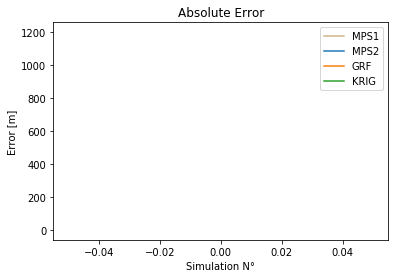

In [6]:
plt.plot(results_frame[results_frame['Type']=='MPS1'].Abs_error.values,color='tan')
plt.plot(results_frame[results_frame['Type']=='MPS2'].Abs_error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Abs_error.values)
plt.plot(results_frame[results_frame['Type']=='KRIG'].Abs_error.values)
plt.legend(['MPS1','MPS2','GRF','KRIG'])
plt.title('Absolute Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
#plt.plot(np.ones(len(pts_0))*2,color='grey',ls='--')


In [ ]:
plt.plot(results_frame[results_frame['Type']=='MPS1'].Error.values,color='tan')
plt.plot(results_frame[results_frame['Type']=='MPS2'].Error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Error.values)
plt.plot(results_frame[results_frame['Type']=='KRIG'].Error.values)
plt.legend(['MPS1','MPS2','GRF','KRIG'])
plt.title('Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')

#plt.plot(np.ones(len(pts_0))*0,color='grey',ls='--')

In [ ]:
plt.plot(results_frame[results_frame['Type']=='MPS1'].Norm_Error.values,color='tan')
plt.plot(results_frame[results_frame['Type']=='MPS2'].Norm_Error.values)
plt.plot(results_frame[results_frame['Type']=='GRF'].Norm_Error.values)
plt.plot(results_frame[results_frame['Type']=='KRIG'].Norm_Error.values)
plt.legend(['MPS1','MPS2','GRF','KRIG'])
plt.title('Normalised Error')
plt.xlabel('Simulation N°')
plt.ylabel('Error [m]')
#plt.plot(np.ones(len(pts_0))*1,color='grey',ls='--')


TypeError: Image data of dtype object cannot be converted to float

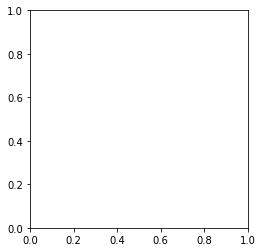

In [7]:
plt.imshow(results_frame[results_frame['Type']=='KRIG'].Sd.values[0])

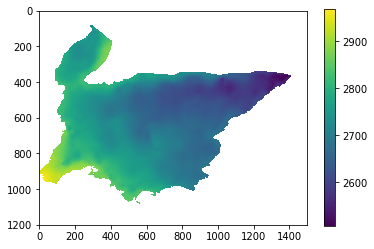

In [22]:
plt.imshow(results_frame[results_frame['Type']=='MPS2'].Mean.values[0])
plt.ylim(1200,0)
plt.xlim(0,1500)
plt.colorbar()

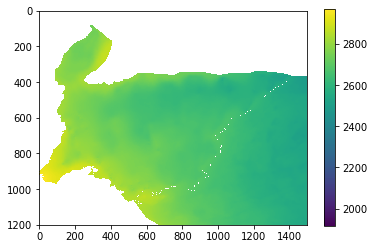

In [25]:
plt.imshow(results_frame[results_frame['Type']=='MPS1'].Mean.values[0])
plt.ylim(1200,0)
plt.xlim(0,1500)
plt.colorbar()

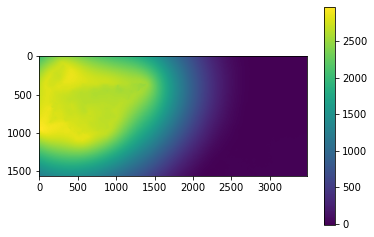

In [28]:
plt.imshow(results_frame[results_frame['Type']=='GRF'].Mean.values[0])
#plt.ylim(1200,0)
#plt.xlim(0,1500)
plt.colorbar()

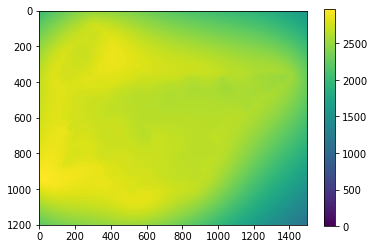

In [27]:
plt.imshow(results_frame[results_frame['Type']=='KRIG'].Mean.values[0])
plt.ylim(1200,0)
plt.xlim(0,1500)
plt.colorbar()

In [25]:
vol_MPS1 = []
vol_MPS2 = []
vol_KRIG = []
vol_GRF = []


for i in range(int(results_frame.shape[0]/4)):
    vol_MPS1.extend(results_frame[results_frame['Type']=='MPS1'].Volume.values[i][:])
    vol_MPS2.extend(results_frame[results_frame['Type']=='MPS2'].Volume.values[i])
    vol_KRIG.extend(results_frame[results_frame['Type']=='KRIG'].Volume.values[i])
    vol_GRF.extend(results_frame[results_frame['Type']=='GRF'].Volume.values[i])

    


Text(0.5, 0, 'Volume [m^2]')

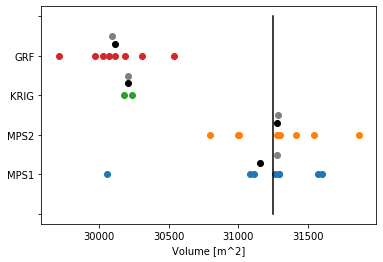

In [28]:
plt.scatter(vol_MPS1,np.ones(len(vol_MPS1)))
plt.scatter(vol_MPS2,np.ones(len(vol_MPS2))+1)
plt.scatter(vol_KRIG,np.ones(len(vol_KRIG))+2)
plt.scatter(vol_GRF,np.ones(len(vol_GRF))+3)
plt.plot([real_vol, real_vol],[0,5],color = 'black')

plt.scatter(np.mean(vol_MPS1),1.3,color = 'black')
plt.scatter(np.mean(vol_MPS2),2.3,color = 'black')
plt.scatter(np.mean(vol_KRIG),3.3,color = 'black')
plt.scatter(np.mean(vol_GRF),4.3,color = 'black')

#plt.text(np.mean(vol_MPS1)+30000,1.3,'Mean')
#plt.text(np.mean(vol_MPS2)+30000,2.3,'Mean')
#plt.text(np.mean(vol_KRIG)+30000,3.3,'Mean')
#plt.text(np.mean(vol_GRF)+30000,4.3,'Mean')

plt.scatter(np.median(vol_MPS1),1.5,color = 'grey')
plt.scatter(np.median(vol_MPS2),2.5,color = 'grey')
plt.scatter(np.median(vol_KRIG),3.5,color = 'grey')
plt.scatter(np.median(vol_GRF),4.5,color = 'grey')

#plt.text(np.median(vol_MPS1)+30000,1.5,'Median')
#plt.text(np.median(vol_MPS2)+30000,2.5,'Median')
#plt.text(np.median(vol_KRIG)+30000,3.5,'Median')
#plt.text(np.median(vol_GRF)+30000,4.5,'Median')

ax = plt.gca()

labels = [item.get_text() for item in ax.get_yticklabels()]
labels[1] = 'Testing'
ax.set_yticklabels(['','','MPS1','MPS2','KRIG','GRF'])



plt.xlabel('Volume [m^2]')